# Spam SMS Detection — BERT Fine-tuning
**Dataset:** UCI SMS Spam Collection  
**Model:** bert-base-uncased  
**Platform:** Kaggle (GPU T4 x2)

In [1]:
# Kiểm tra GPU
import torch
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

CUDA available: True
GPU: Tesla T4
Memory: 15.6 GB


In [2]:
!pip install transformers -q

## 1. Load & Explore Data

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from glob import glob

matches = glob("/kaggle/input/**/spam.csv", recursive=True)
assert matches, "Không tìm thấy spam.csv trong /kaggle/input — kiểm tra lại dataset đã add chưa"
DATA_PATH = matches[0]
print(f"Data path: {DATA_PATH}")

df = pd.read_csv(DATA_PATH, encoding="latin-1")[["v1", "v2"]]
df.columns = ["label", "text"]
df["label"] = df["label"].map({"ham": 0, "spam": 1})
df.drop_duplicates(subset="text", inplace=True)
df.reset_index(drop=True, inplace=True)

print(f"Total: {len(df)} | Ham: {(df.label==0).sum()} | Spam: {(df.label==1).sum()}")
df.head()

Data path: /kaggle/input/datasets/qhuyisthebest/spam-sms/spam.csv
Total: 5169 | Ham: 4516 | Spam: 653


,label,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


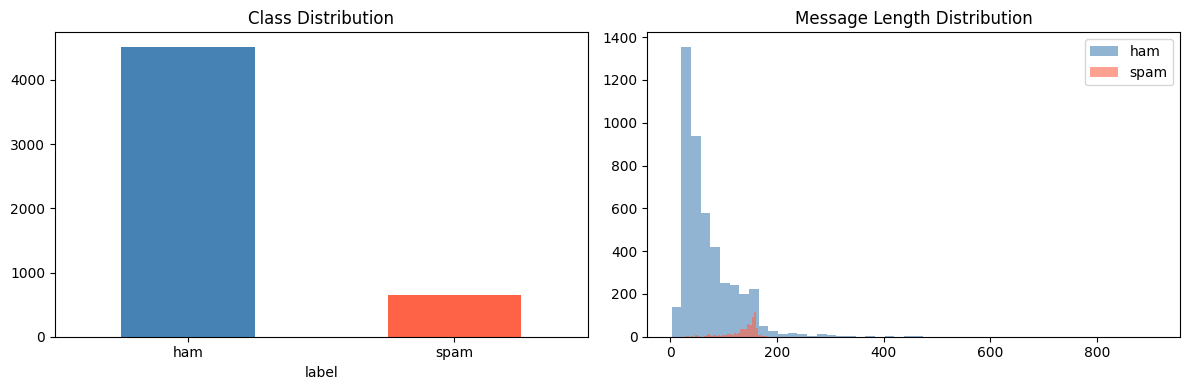

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df["label"].value_counts().rename({0: "ham", 1: "spam"}).plot(
    kind="bar", ax=axes[0], color=["steelblue", "tomato"], rot=0
)
axes[0].set_title("Class Distribution")

df["char_count"] = df["text"].apply(len)
for label, color, name in [(0, "steelblue", "ham"), (1, "tomato", "spam")]:
    axes[1].hist(df[df.label == label]["char_count"], bins=50, alpha=0.6, color=color, label=name)
axes[1].set_title("Message Length Distribution")
axes[1].legend()

plt.tight_layout()
plt.show()

## 2. Train / Test Split

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    df["text"].values, df["label"].values,
    test_size=0.2, random_state=42, stratify=df["label"]
)

print(f"Train: {len(X_train)} | Test: {len(X_test)}")
print(f"Train spam ratio: {y_train.mean():.3f}")
print(f"Test  spam ratio: {y_test.mean():.3f}")

Train: 4135 | Test: 1034
Train spam ratio: 0.126
Test  spam ratio: 0.127


## 3. Dataset & DataLoader

In [6]:
from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizerFast

MAX_LEN = 128
BATCH_SIZE = 32
MODEL_NAME = "bert-base-uncased"

tokenizer = BertTokenizerFast.from_pretrained(MODEL_NAME)


class SMSDataset(Dataset):
    def __init__(self, texts, labels):
        self.encodings = tokenizer(
            list(texts), truncation=True, padding="max_length",
            max_length=MAX_LEN, return_tensors="pt"
        )
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            "input_ids": self.encodings["input_ids"][idx],
            "attention_mask": self.encodings["attention_mask"][idx],
            "labels": self.labels[idx],
        }


train_dataset = SMSDataset(X_train, y_train)
test_dataset  = SMSDataset(X_test,  y_test)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"Train batches: {len(train_loader)} | Test batches: {len(test_loader)}")

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Train batches: 130 | Test batches: 33


## 4. Model Setup

In [7]:
from transformers import BertForSequenceClassification, get_linear_schedule_with_warmup
from torch.optim import AdamW

DEVICE    = torch.device("cuda" if torch.cuda.is_available() else "cpu")
EPOCHS    = 8       # EarlyStopping sẽ dừng sớm hơn nếu không cải thiện
PATIENCE  = 2       # dừng sau 2 epoch liên tiếp không tăng F1
LR        = 2e-5

model = BertForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)
model.to(DEVICE)

optimizer = AdamW(model.parameters(), lr=LR, weight_decay=0.01)

total_steps  = len(train_loader) * EPOCHS
warmup_steps = int(0.1 * total_steps)
scheduler    = get_linear_schedule_with_warmup(optimizer, warmup_steps, total_steps)

# Weighted loss để xử lý class imbalance
n_ham  = (y_train == 0).sum()
n_spam = (y_train == 1).sum()
weight  = torch.tensor([1.0, n_ham / n_spam], dtype=torch.float).to(DEVICE)
loss_fn = torch.nn.CrossEntropyLoss(weight=weight)

print(f"Max epochs: {EPOCHS} | Early stopping patience: {PATIENCE}")
print(f"Total steps: {total_steps} | Warmup: {warmup_steps}")
print(f"Class weight — ham: 1.0 | spam: {n_ham/n_spam:.2f}")

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Max epochs: 8 | Early stopping patience: 2
Total steps: 1040 | Warmup: 104
Class weight — ham: 1.0 | spam: 6.92


## 5. Training Loop

In [8]:
from sklearn.metrics import classification_report, roc_auc_score
from tqdm.notebook import tqdm
import os

SAVE_DIR = "/kaggle/working/bert_spam"
os.makedirs(SAVE_DIR, exist_ok=True)


def evaluate(model, loader):
    model.eval()
    total_loss = 0
    all_preds, all_labels, all_probas = [], [], []
    with torch.no_grad():
        for batch in loader:
            input_ids      = batch["input_ids"].to(DEVICE)
            attention_mask = batch["attention_mask"].to(DEVICE)
            labels         = batch["labels"].to(DEVICE)
            outputs        = model(input_ids=input_ids, attention_mask=attention_mask)
            loss           = loss_fn(outputs.logits, labels)
            total_loss    += loss.item()
            probs  = torch.softmax(outputs.logits, dim=1)[:, 1].cpu().numpy()
            preds  = (probs >= 0.5).astype(int)
            all_preds.extend(preds)
            all_labels.extend(labels.cpu().numpy())
            all_probas.extend(probs)
    return {
        "loss":   total_loss / len(loader),
        "preds":  np.array(all_preds),
        "labels": np.array(all_labels),
        "probas": np.array(all_probas),
    }


history    = {"train_loss": [], "val_loss": [], "val_f1": [], "val_auc": []}
best_f1    = 0.0
no_improve = 0

for epoch in range(EPOCHS):
    # --- Train ---
    model.train()
    total_loss = 0
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}")
    for batch in pbar:
        input_ids      = batch["input_ids"].to(DEVICE)
        attention_mask = batch["attention_mask"].to(DEVICE)
        labels         = batch["labels"].to(DEVICE)
        optimizer.zero_grad()
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        loss    = loss_fn(outputs.logits, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        total_loss += loss.item()
        pbar.set_postfix({"loss": f"{loss.item():.4f}"})

    avg_train_loss = total_loss / len(train_loader)

    # --- Eval ---
    val     = evaluate(model, test_loader)
    report  = classification_report(val["labels"], val["preds"], target_names=["ham", "spam"], output_dict=True)
    f1      = report["spam"]["f1-score"]
    roc_auc = roc_auc_score(val["labels"], val["probas"])

    history["train_loss"].append(avg_train_loss)
    history["val_loss"].append(val["loss"])
    history["val_f1"].append(f1)
    history["val_auc"].append(roc_auc)

    print(f"Epoch {epoch+1} | train_loss={avg_train_loss:.4f} | val_loss={val['loss']:.4f} | spam_f1={f1:.4f} | roc_auc={roc_auc:.4f}")

    if f1 > best_f1:
        best_f1    = f1
        no_improve = 0
        model.save_pretrained(SAVE_DIR)
        tokenizer.save_pretrained(SAVE_DIR)
        print(f"  ✓ Saved best model (F1={best_f1:.4f})")
    else:
        no_improve += 1
        print(f"  No improvement ({no_improve}/{PATIENCE})")
        if no_improve >= PATIENCE:
            print(f"  Early stopping triggered at epoch {epoch+1}")
            break

print(f"\nBest F1: {best_f1:.4f} | Stopped at epoch {epoch+1}/{EPOCHS}")

Epoch 1/8:   0%|          | 0/130 [00:00<?, ?it/s]

Epoch 1 | train_loss=0.3118 | val_loss=0.0922 | spam_f1=0.9685 | roc_auc=0.9992


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  ✓ Saved best model (F1=0.9685)


Epoch 2/8:   0%|          | 0/130 [00:00<?, ?it/s]

...

  ✓ Saved best model (F1=0.9810)


Epoch 3/8:   0%|          | 0/130 [00:00<?, ?it/s]

Epoch 3 | train_loss=0.0195 | val_loss=0.0355 | spam_f1=0.9225 | roc_auc=0.9996
  No improvement (1/2)


Epoch 4/8:   0%|          | 0/130 [00:00<?, ?it/s]

Epoch 4 | train_loss=0.0073 | val_loss=0.0659 | spam_f1=0.9730 | roc_auc=0.9995
  No improvement (2/2)
  Early stopping triggered at epoch 4

Best F1: 0.9810 | Stopped at epoch 4/8


## 6. Training Curves

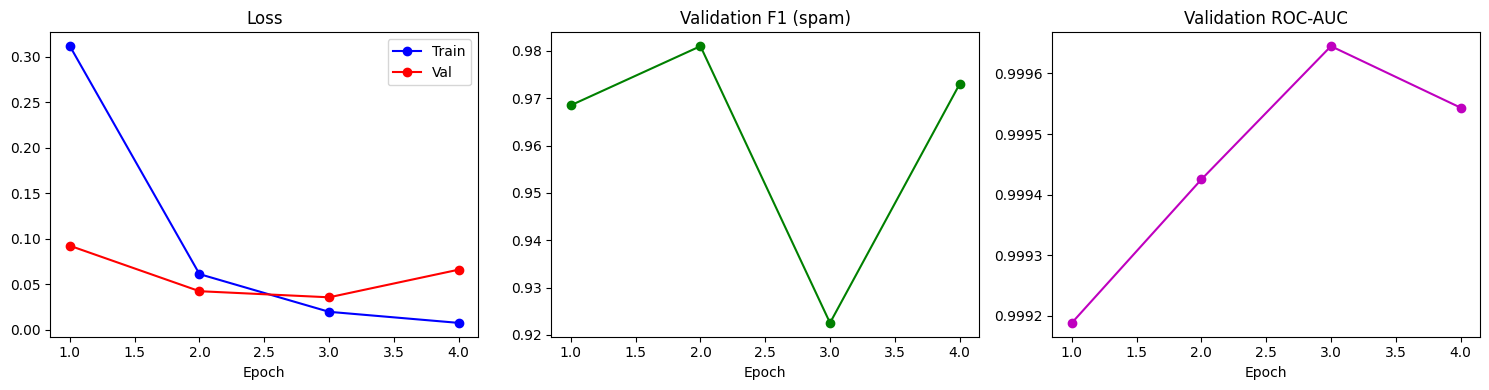

Trained for 4 epoch(s) out of max 8


In [9]:
actual_epochs = len(history["val_f1"])
epochs_range  = range(1, actual_epochs + 1)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(epochs_range, history["train_loss"], "b-o", label="Train")
axes[0].plot(epochs_range, history["val_loss"],   "r-o", label="Val")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(epochs_range, history["val_f1"], "g-o")
axes[1].set_title("Validation F1 (spam)")
axes[1].set_xlabel("Epoch")

axes[2].plot(epochs_range, history["val_auc"], "m-o")
axes[2].set_title("Validation ROC-AUC")
axes[2].set_xlabel("Epoch")

plt.tight_layout()
plt.savefig("/kaggle/working/bert_history.png", dpi=120)
plt.show()
print(f"Trained for {actual_epochs} epoch(s) out of max {EPOCHS}")

## 7. Final Evaluation (Best Model)

In [10]:
from sklearn.metrics import confusion_matrix, roc_curve, auc
from transformers import BertForSequenceClassification

best_model = BertForSequenceClassification.from_pretrained(SAVE_DIR)
best_model.to(DEVICE)

val = evaluate(best_model, test_loader)

print("Classification Report:")
print(classification_report(val["labels"], val["preds"], target_names=["ham", "spam"]))
print(f"ROC-AUC: {roc_auc_score(val['labels'], val['probas']):.4f}")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Classification Report:
              precision    recall  f1-score   support

         ham       1.00      1.00      1.00       903
        spam       0.98      0.98      0.98       131

    accuracy                           1.00      1034
   macro avg       0.99      0.99      0.99      1034
weighted avg       1.00      1.00      1.00      1034

ROC-AUC: 0.9994


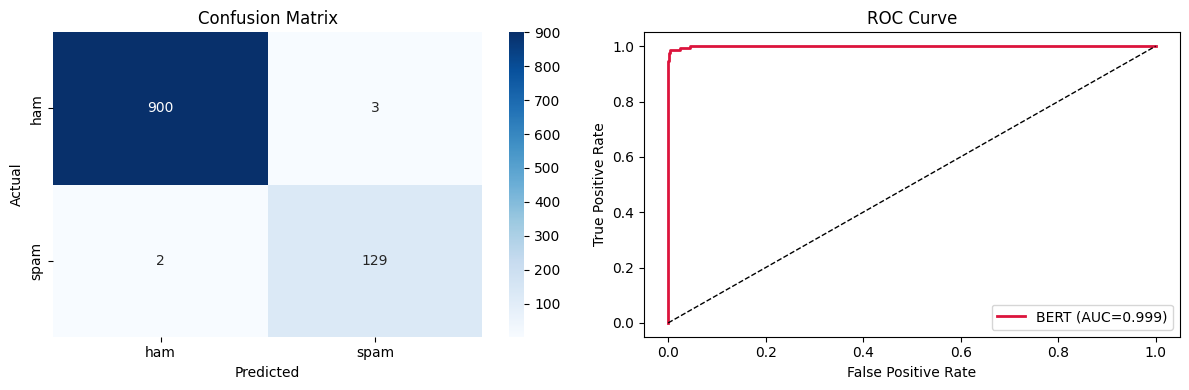

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Confusion matrix
cm = confusion_matrix(val["labels"], val["preds"])
sns.heatmap(cm, annot=True, fmt="d", ax=axes[0], cmap="Blues",
            xticklabels=["ham", "spam"], yticklabels=["ham", "spam"])
axes[0].set_title("Confusion Matrix")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

# ROC curve
fpr, tpr, _ = roc_curve(val["labels"], val["probas"])
roc_auc     = auc(fpr, tpr)
axes[1].plot(fpr, tpr, color="crimson", lw=2, label=f"BERT (AUC={roc_auc:.3f})")
axes[1].plot([0,1], [0,1], "k--", lw=1)
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve")
axes[1].legend()

plt.tight_layout()
plt.savefig("/kaggle/working/bert_eval.png", dpi=120)
plt.show()

## 8. Test Thử Vài Tin Nhắn

In [12]:
def predict(text: str, model=best_model) -> dict:
    enc = tokenizer(
        text, truncation=True, padding="max_length",
        max_length=MAX_LEN, return_tensors="pt"
    )
    model.eval()
    with torch.no_grad():
        logits = model(
            input_ids=enc["input_ids"].to(DEVICE),
            attention_mask=enc["attention_mask"].to(DEVICE)
        ).logits
    proba = torch.softmax(logits, dim=1)[0][1].item()
    return {"label": "SPAM" if proba >= 0.5 else "HAM", "confidence": round(proba, 4)}


test_messages = [
    "Congratulations! You've won a $1000 gift card. Click here to claim now!",
    "Hey, are you coming to the meeting tomorrow at 10am?",
    "FREE entry in 2 a weekly comp to win FA Cup final tkts 21st May 2005.",
    "Can you pick up some groceries on your way home?",
    "URGENT: Your account has been suspended. Verify now at http://bit.ly/xxx",
    "I'll be there in 5 minutes, save me a seat.",
]

print(f"{'Message':<60} {'Label':<6} {'Confidence'}")
print("-" * 80)
for msg in test_messages:
    result = predict(msg)
    print(f"{msg[:58]:<60} {result['label']:<6} {result['confidence']:.4f}")

Message                                                      Label  Confidence
--------------------------------------------------------------------------------
Congratulations! You've won a $1000 gift card. Click here    SPAM   0.9979
Hey, are you coming to the meeting tomorrow at 10am?         HAM    0.0019
FREE entry in 2 a weekly comp to win FA Cup final tkts 21s   SPAM   0.9985
Can you pick up some groceries on your way home?             HAM    0.0028
URGENT: Your account has been suspended. Verify now at htt   SPAM   0.9988
I'll be there in 5 minutes, save me a seat.                  HAM    0.0016


## 9. Save Output Files

In [13]:
import json

report_dict = classification_report(
    val["labels"], val["preds"],
    target_names=["ham", "spam"], output_dict=True
)

metrics = {
    "accuracy":  round(report_dict["accuracy"], 4),
    "precision": round(report_dict["spam"]["precision"], 4),
    "recall":    round(report_dict["spam"]["recall"], 4),
    "f1":        round(report_dict["spam"]["f1-score"], 4),
    "roc_auc":   round(roc_auc_score(val["labels"], val["probas"]), 4),
}

with open("/kaggle/working/bert_metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)

print("Saved files:")
print("  /kaggle/working/bert_spam/     — model weights")
print("  /kaggle/working/bert_metrics.json")
print("  /kaggle/working/bert_history.png")
print("  /kaggle/working/bert_eval.png")
print("\nMetrics:")
for k, v in metrics.items():
    print(f"  {k}: {v}")

Saved files:
  /kaggle/working/bert_spam/     — model weights
  /kaggle/working/bert_metrics.json
  /kaggle/working/bert_history.png
  /kaggle/working/bert_eval.png

Metrics:
  accuracy: 0.9952
  precision: 0.9773
  recall: 0.9847
  f1: 0.981
  roc_auc: 0.9994


In [14]:
from huggingface_hub import HfApi
from kaggle_secrets import UserSecretsClient


# Token lưu trong Kaggle Secrets (Add-ons → Secrets → HF_TOKEN)
token = UserSecretsClient().get_secret("HF_TOKEN")


api = HfApi()
api.upload_folder(
   folder_path="/kaggle/working/bert_spam",
   repo_id="qhuyisthebest/bert-spam",
   token=token,
)
print("Done! Model pushed to https://huggingface.co/qhuyisthebest/bert-spam")

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

Done! Model pushed to https://huggingface.co/qhuyisthebest/bert-spam
